In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, roc_auc_score, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


from fantasy_football.fpl_api.get_performance_data import get_most_recent_gw_points
from fantasy_football.model.base_models.in_season import (
    DEFAULT_IN_SEASON_ARTIFACT_PATH,
    DEFAULT_IN_SEASON_SCORES_PATH,
    build_inseason_fixture_features,
)
from fantasy_football.model.training.utils import (
    create_correlation_matrix,
    load_gw_data,
)
from fantasy_football.utils import create_optimal_team
from fantasy_football.fpl_api.get_live_data import LivePlayerData

RANDOM_STATE = 12

In [2]:
historic_data = load_gw_data("2024-25")
historic_data.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,...,1,0.0,2,0,0,0,50,False,0,1
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,...,1,0.0,0,0,0,0,45,True,0,1
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,...,2,0.0,0,0,0,0,50,True,0,1
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,...,2,0.0,0,0,0,0,45,False,0,1
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,...,1,16.0,1,0,0,0,55,False,1,1


In [3]:
target_variable = "total_points"

historic_data[target_variable].describe()

count    27605.000000
mean         1.200906
std          2.416882
min         -5.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         25.000000
Name: total_points, dtype: float64

# Features from lagged columns

In [4]:
print(historic_data.columns)

Index(['name', 'position', 'team', 'xP', 'assists', 'bonus', 'bps',
       'clean_sheets', 'creativity', 'element', 'expected_assists',
       'expected_goal_involvements', 'expected_goals',
       'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored',
       'ict_index', 'influence', 'kickoff_time', 'minutes', 'mng_clean_sheets',
       'mng_draw', 'mng_goals_scored', 'mng_loss', 'mng_underdog_draw',
       'mng_underdog_win', 'mng_win', 'modified', 'opponent_team', 'own_goals',
       'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves',
       'selected', 'starts', 'team_a_score', 'team_h_score', 'threat',
       'total_points', 'transfers_balance', 'transfers_in', 'transfers_out',
       'value', 'was_home', 'yellow_cards', 'GW'],
      dtype='object')


In [5]:
historic_data = build_inseason_fixture_features(historic_data)
calculated_features = [col for col in historic_data.columns if "calc_" in col]


In [6]:
correlation_matrix = create_correlation_matrix(
    historic_data, 
    columns=calculated_features, 
    target_variable=target_variable)

correlation_matrix

total_points                                    1.000000
calc_ict_index_mean_last_12_fixtures            0.464041
calc_ict_index_mean_last_9_fixtures             0.463279
calc_ict_index_mean_last_6_fixtures             0.461945
calc_minutes_mean_last_3_fixtures               0.460957
                                                  ...   
calc_threat_stdev_last_1_fixtures                    NaN
calc_transfers_balance_stdev_last_1_fixtures         NaN
calc_value_stdev_last_1_fixtures                     NaN
calc_yellow_cards_stdev_last_1_fixtures              NaN
calc_minutes_stdev_last_1_fixtures                   NaN
Name: total_points, Length: 191, dtype: float64

# MVP model

In [7]:
# Split by complete gameweeks so future results never leak into training
validation_fraction = 0.2

train_index, valid_index = train_test_split(
    historic_data.index, test_size=0.20, random_state=RANDOM_STATE
)
X_train = historic_data.loc[train_index, calculated_features].copy()
y_train = historic_data.loc[train_index, target_variable].copy()

X_valid = historic_data.loc[valid_index, calculated_features].copy()
y_valid = historic_data.loc[valid_index, target_variable].copy()

print(f"Train players: {len(X_train):,}; validation players: {len(X_valid):,}")


Train players: 22,084; validation players: 5,521


## Dummy model

In [8]:
from sklearn.dummy import DummyRegressor

models = {}
validation_predictions = {}

dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_train, y_train)
models["Dummy"] = dummy_model
validation_predictions["Dummy"] = dummy_model.predict(X_valid)

## Unweighted

In [9]:
def fit_catboost(sample_weight=None):
    fitted_model = CatBoostRegressor(
        iterations=163,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    )
    fitted_model.fit(
        X_train,
        y_train,
        sample_weight=sample_weight,
    )
    return fitted_model

unweighted_model = fit_catboost()
models["Unweighted"] = unweighted_model
validation_predictions["Unweighted"] = unweighted_model.predict(X_valid)

## Basic weighting
Weights higher if score was > 6 in GW

In [10]:
# Give high-scoring returns extra influence during training.
basic_weights = pd.Series(1.0, index=y_train.index)
basic_weights.loc[y_train > 6] = 4.0

basic_weighting_model = fit_catboost(sample_weight=basic_weights)
models["BASIC weighting"] = basic_weighting_model
validation_predictions["BASIC weighting"] = basic_weighting_model.predict(X_valid)

## Percentile weighting
Weights increase with the player's score percentile within their training gameweek.

In [11]:
train_gameweeks = historic_data.loc[y_train.index, "GW"]
score_percentiles = y_train.groupby(train_gameweeks).rank(pct=True, method="average")
percentile_weights = pd.cut(
    score_percentiles,
    bins=[0, 0.25, 0.50, 0.75, 0.90, 1.0],
    labels=[1.0, 1.5, 2.0, 3.0, 4.0],
    include_lowest=True,
).astype(float)

percentile_weighting_model = fit_catboost(sample_weight=percentile_weights)
models["Percentile weighting"] = percentile_weighting_model
validation_predictions["Percentile weighting"] = percentile_weighting_model.predict(X_valid)

# Comparison table
## All validation points

In [12]:
def evaluate_predictions(predictions, top_fraction=0.10):
    evaluation = pd.DataFrame({
        "GW": historic_data.loc[y_valid.index, "GW"].to_numpy(),
        "actual": y_valid.to_numpy(),
        "predicted": predictions,
    })

    top_end_by_gw = []
    for _, gameweek in evaluation.groupby("GW"):
        n = max(1, int(np.ceil(len(gameweek) * top_fraction)))
        predicted_top = gameweek.nlargest(n, "predicted")
        actual_top_indices = set(gameweek.nlargest(n, "actual").index)
        top_end_by_gw.append({
            "top_decile_avg_actual_points": predicted_top["actual"].mean(),
            "top_decile_hit_rate": predicted_top.index.isin(actual_top_indices).mean(),
            "top_decile_oracle_regret": (
                gameweek.nlargest(n, "actual")["actual"].mean()
                - predicted_top["actual"].mean()
            ),
        })

    top_end = pd.DataFrame(top_end_by_gw).mean()
    return {
        "MAE": mean_absolute_error(evaluation["actual"], evaluation["predicted"]),
        "RMSE": root_mean_squared_error(evaluation["actual"], evaluation["predicted"]),
        "R2": r2_score(evaluation["actual"], evaluation["predicted"]),
        **top_end.to_dict(),
        **{
            f"absolute_error_p{percentile}": evaluation["actual"]
            .sub(evaluation["predicted"])
            .abs()
            .quantile(percentile / 100)
            for percentile in (25, 50, 75, 90)
        },
    }

comparison_table = pd.DataFrame.from_dict(
    {name: evaluate_predictions(preds) for name, preds in validation_predictions.items()},
    orient="index",
).rename_axis("model").reset_index()

comparison_table = comparison_table.sort_values(
    "top_decile_avg_actual_points", ascending=False
).reset_index(drop=True)
# Unweighted has the best MAE, RMSE and R², so it remains the selected model.
model = models["Unweighted"]

comparison_table.round(3)

,model,MAE,RMSE,R2,top_decile_avg_actual_points,top_decile_hit_rate,top_decile_oracle_regret,absolute_error_p25,absolute_error_p50,absolute_error_p75,absolute_error_p90
0,BASIC weighting,1.393,2.205,0.163,3.936,0.383,3.251,0.158,0.608,2.195,3.772
1,Percentile weighting,1.283,2.051,0.276,3.907,0.379,3.279,0.192,0.607,1.942,3.126
2,Unweighted,1.065,1.993,0.316,3.892,0.375,3.294,0.113,0.338,1.272,2.817
3,Dummy,1.530,2.411,-0.000,1.171,0.120,6.016,0.797,1.203,1.203,2.797


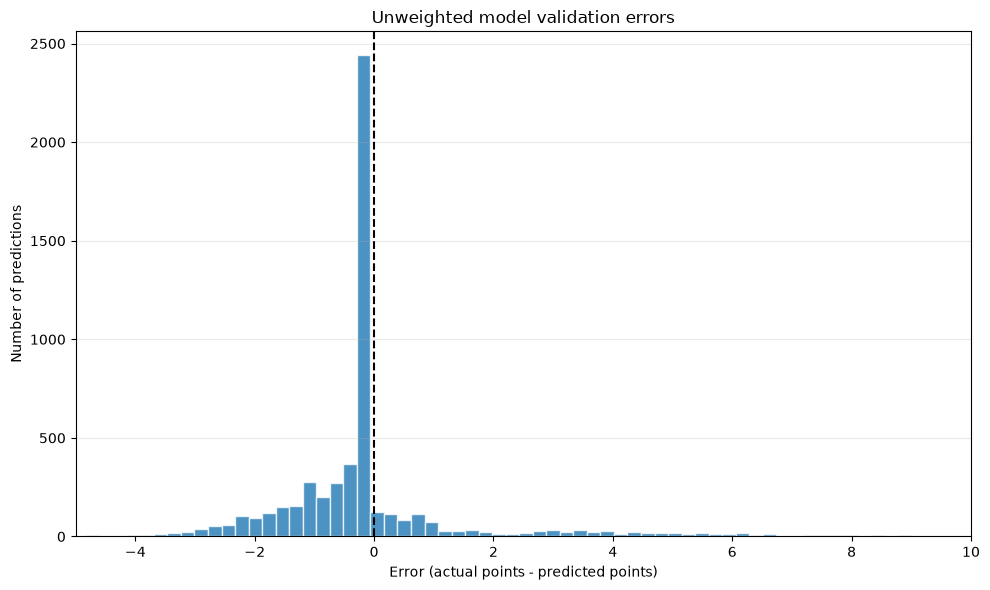

In [13]:
unweighted_errors = y_valid.to_numpy() - validation_predictions["Unweighted"]

figure, axis = plt.subplots(figsize=(10, 6))
axis.hist(unweighted_errors, bins=100, edgecolor="white", alpha=0.8)
axis.axvline(0, color="black", linestyle="--", linewidth=1.5)
axis.set_xlim(-5, 10)
axis.set(
    title="Unweighted model validation errors",
    xlabel="Error (actual points - predicted points)",
    ylabel="Number of predictions",
)
axis.grid(axis="y", alpha=0.25)
figure.tight_layout()


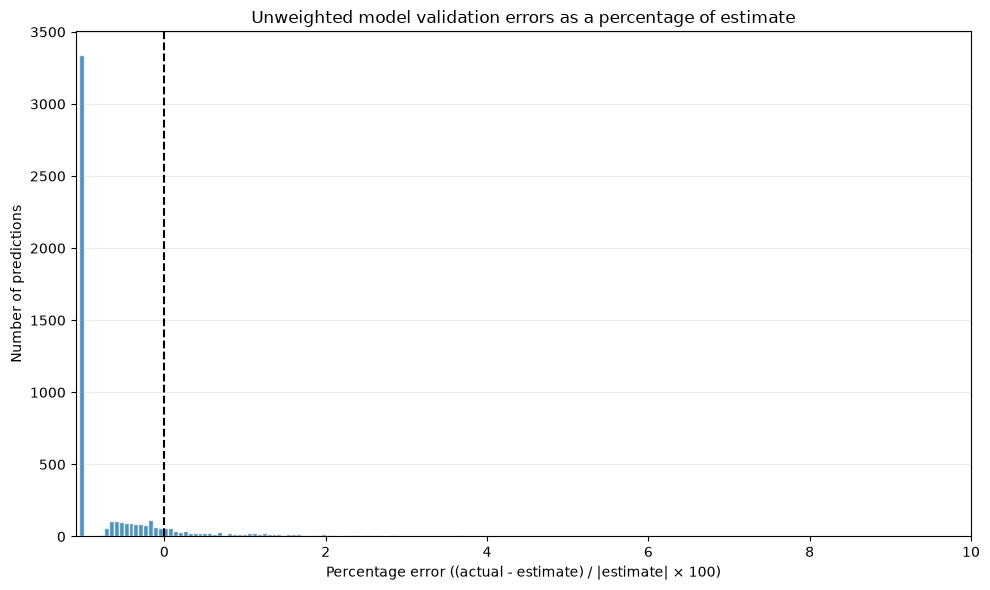

In [14]:
unweighted_estimates = pd.Series(
    validation_predictions["Unweighted"], index=y_valid.index
)
nonzero_estimate = unweighted_estimates.abs().gt(1e-9)
unweighted_percentage_errors = (
    (y_valid.loc[nonzero_estimate] - unweighted_estimates.loc[nonzero_estimate])
    / unweighted_estimates.loc[nonzero_estimate].abs()
)

figure, axis = plt.subplots(figsize=(10, 6))
axis.hist(unweighted_percentage_errors, bins=1000, edgecolor="white", alpha=0.8)
axis.axvline(0, color="black", linestyle="--", linewidth=1.5)
axis.set(
    title="Unweighted model validation errors as a percentage of estimate",
    xlabel="Percentage error ((actual - estimate) / |estimate| × 100)",
    ylabel="Number of predictions",
)
axis.grid(axis="y", alpha=0.25)
axis.set_xlim(-1.1, 10)
figure.tight_layout()


## Top-decile hit rate by gameweek


,model,GW,top_decile_hit_rate
0,Dummy,1,0.076923
1,Dummy,2,0.000000
2,Dummy,3,0.307692
3,Dummy,4,0.230769
4,Dummy,5,0.307692
...,...,...,...
147,Percentile weighting,34,0.538462
148,Percentile weighting,35,0.437500
149,Percentile weighting,36,0.647059
150,Percentile weighting,37,0.437500


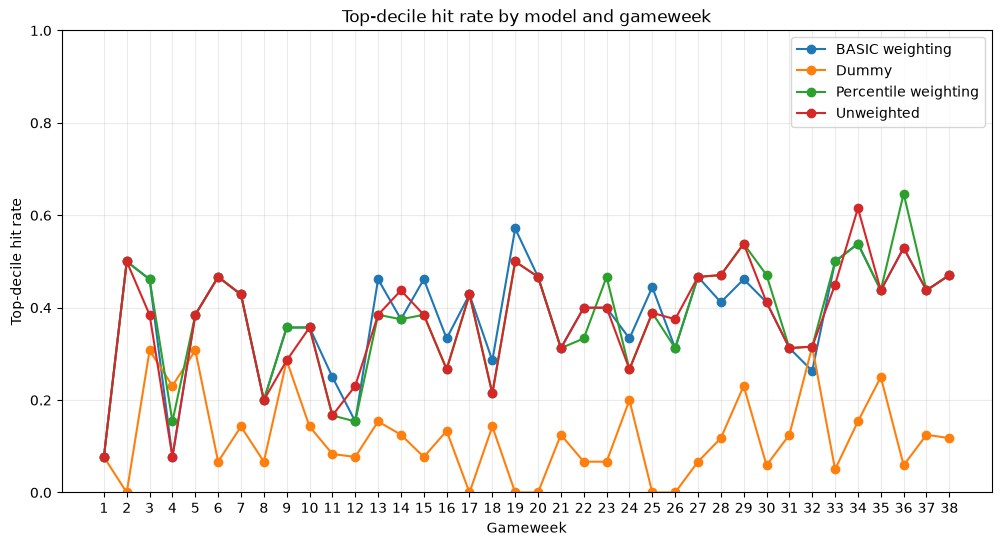

In [15]:
def calculate_top_decile_hit_rate_by_gameweek(
    predictions_by_model, actual, gameweeks, top_fraction=0.10
):
    '''Return one top-decile hit-rate observation per model and gameweek.'''
    records = []
    for model_name, predictions in predictions_by_model.items():
        evaluation = pd.DataFrame(
            {
                "GW": gameweeks.to_numpy(),
                "actual": actual.to_numpy(),
                "predicted": predictions,
            },
            index=actual.index,
        )
        for gameweek, gameweek_data in evaluation.groupby("GW"):
            n = max(1, int(np.ceil(len(gameweek_data) * top_fraction)))
            predicted_top = gameweek_data.nlargest(n, "predicted")
            actual_top_indices = set(gameweek_data.nlargest(n, "actual").index)
            records.append(
                {
                    "model": model_name,
                    "GW": gameweek,
                    "top_decile_hit_rate": predicted_top.index.isin(
                        actual_top_indices
                    ).mean(),
                }
            )
    return pd.DataFrame(records)


def plot_top_decile_hit_rate_by_gameweek(
    predictions_by_model, actual, gameweeks, top_fraction=0.10, ax=None
):
    '''Plot every model's top-decile hit rate against gameweek.'''
    hit_rates = calculate_top_decile_hit_rate_by_gameweek(
        predictions_by_model, actual, gameweeks, top_fraction=top_fraction
    )
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))

    for model_name, model_results in hit_rates.groupby("model"):
        model_results = model_results.sort_values("GW")
        ax.plot(
            model_results["GW"],
            model_results["top_decile_hit_rate"],
            marker="o",
            linewidth=1.5,
            label=model_name,
        )

    ax.set(
        xlabel="Gameweek",
        ylabel="Top-decile hit rate",
        title="Top-decile hit rate by model and gameweek",
        ylim=(0, 1),
    )
    ax.set_xticks(sorted(hit_rates["GW"].unique()))
    ax.grid(alpha=0.25)
    ax.legend()
    return hit_rates, ax


hit_rate_by_gameweek, hit_rate_axis = plot_top_decile_hit_rate_by_gameweek(
    validation_predictions,
    y_valid,
    historic_data.loc[y_valid.index, "GW"],
)
hit_rate_by_gameweek


## By GW


In [16]:
validation_dataset = historic_data.loc[valid_index]
validation_dataset['top_decile_size'] = np.ceil(
    validation_dataset.groupby('GW')['total_points'].transform('size') * 0.10
).astype(int)
validation_dataset['actual_player_rank_in_gw'] = validation_dataset.groupby('GW')['total_points'].rank(ascending=False, method='first')
validation_dataset['actual_top_decile_player'] = np.where(
    validation_dataset['actual_player_rank_in_gw'] <= validation_dataset['top_decile_size'], 1, 0
)

for model, preds in validation_predictions.items():
    validation_dataset[model] = preds
    validation_dataset[f'{model}_predicted_player_rank_in_gw'] = validation_dataset.groupby('GW')[model].rank(ascending=False, method='first')
    validation_dataset[f'{model}_rank_delta'] = validation_dataset['actual_player_rank_in_gw'] - validation_dataset[f'{model}_predicted_player_rank_in_gw']

    validation_dataset[f'{model}_predicted_top_decile_player'] = np.where(
        validation_dataset[f'{model}_predicted_player_rank_in_gw'] <= validation_dataset['top_decile_size'], 1, 0
    )




# Selected production model

The **Unweighted CatBoost model** is selected because it has the best MAE, RMSE and R². Percentile weighting is marginally better on the top-decile metrics, but its general point-estimation error is materially worse. The export is deliberately hard-coded to the unweighted approach.

Validation metrics above come from models fitted only on the training split. After selection, the production model below is deliberately refitted on all 2024/25 development rows. This does not alter the recorded validation predictions or metrics; it creates a separate final artifact that uses the validation rows as additional training data for future 2025/26 predictions. A later season is still required for a final untouched evaluation.


In [17]:
X_full = historic_data[calculated_features].copy()
y_full = historic_data[target_variable].copy()

final_in_season_model = CatBoostRegressor(
    iterations=163,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)
final_in_season_model.fit(X_full, y_full)

DEFAULT_IN_SEASON_ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(
    {
        "model": final_in_season_model,
        "model_name": "Unweighted",
        "feature_columns": calculated_features,
    },
    DEFAULT_IN_SEASON_ARTIFACT_PATH,
)
print(f"Saved unweighted in-season model to {DEFAULT_IN_SEASON_ARTIFACT_PATH}")

# Generate fixture-level 2025/26 scores for the ensemble.
fixtures_2025_26 = build_inseason_fixture_features(load_gw_data("2025-26"))
inseason_scores_2025_26 = fixtures_2025_26[["element", "fixture", "GW", "name"]].copy()
inseason_scores_2025_26["inseason_model_score"] = final_in_season_model.predict(
    fixtures_2025_26[calculated_features]
)
joblib.dump(inseason_scores_2025_26, DEFAULT_IN_SEASON_SCORES_PATH)
print(f"Saved 2025/26 in-season scores to {DEFAULT_IN_SEASON_SCORES_PATH}")


Saved unweighted in-season model to /Users/calumthompson/Documents/fantasy_football_v2/fantasy_football/model/artifacts/in_season_model.joblib


Saved 2025/26 in-season scores to /Users/calumthompson/Documents/fantasy_football_v2/fantasy_football/model/artifacts/in_season_scores_2025_26.joblib
